Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loaded events: 492 / bounces: 243
rallies detected: 19 (gap>240 frames = 2.0s)
Rally 1: 3 bounces (frames 64..156)


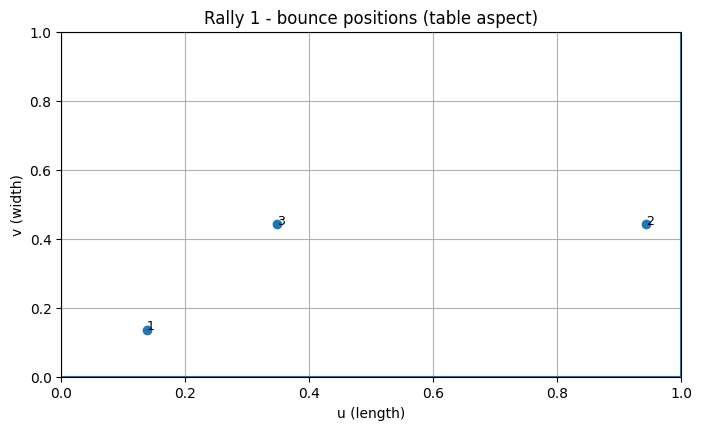

Rally 2: 2 bounces (frames 838..899)


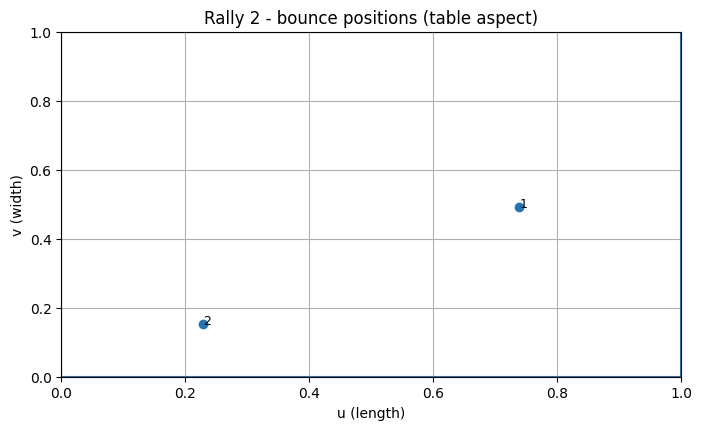

Rally 3: 24 bounces (frames 1219..2979)


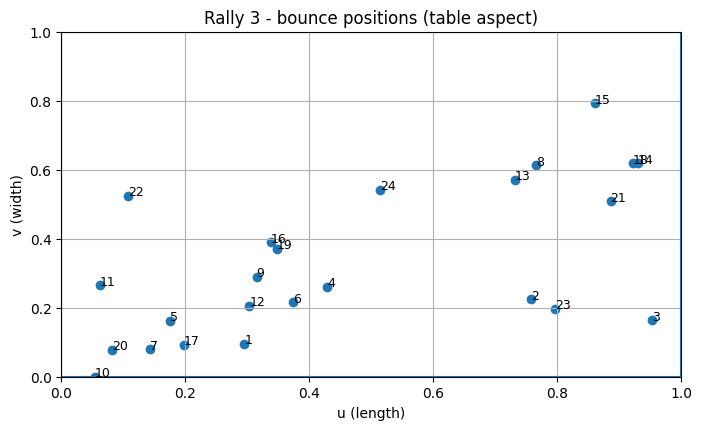

Rally 4: 21 bounces (frames 3400..4470)


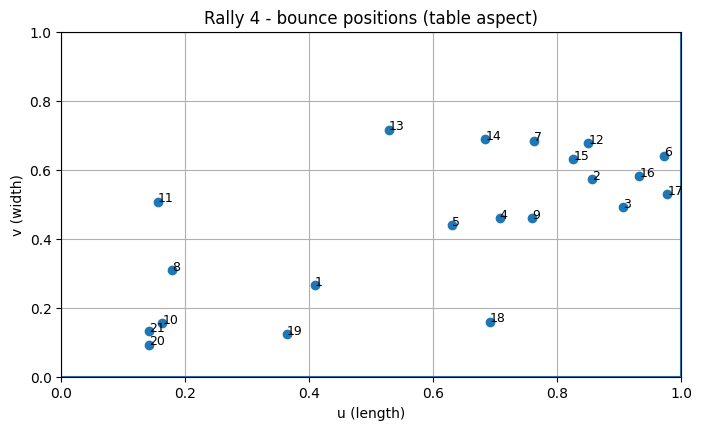

Rally 5: 7 bounces (frames 4886..5363)


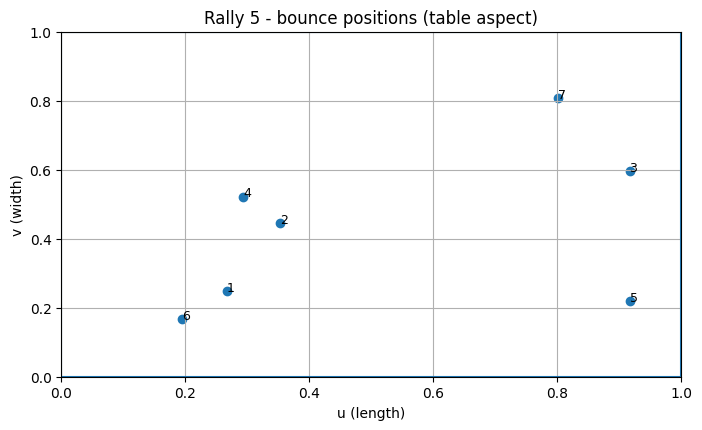

Rally 6: 6 bounces (frames 5888..6189)


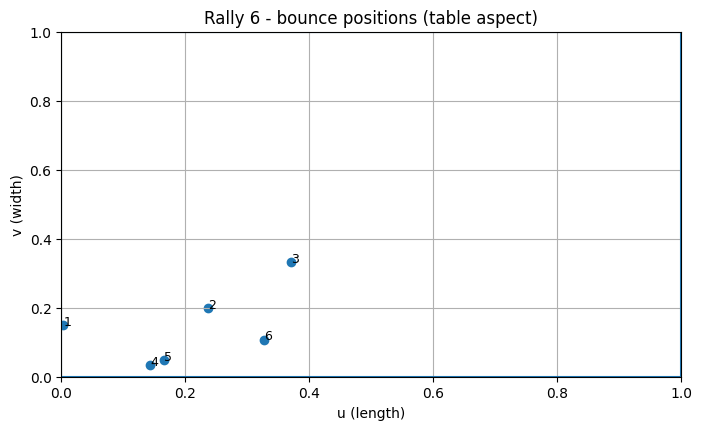

Rally 7: 14 bounces (frames 7328..8366)


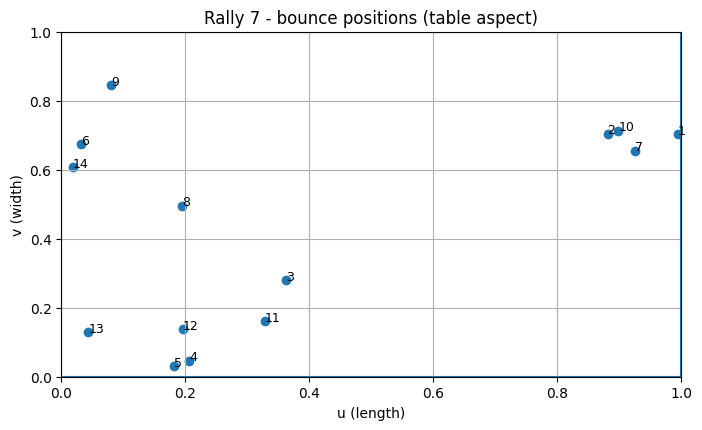

Rally 8: 6 bounces (frames 8848..9053)


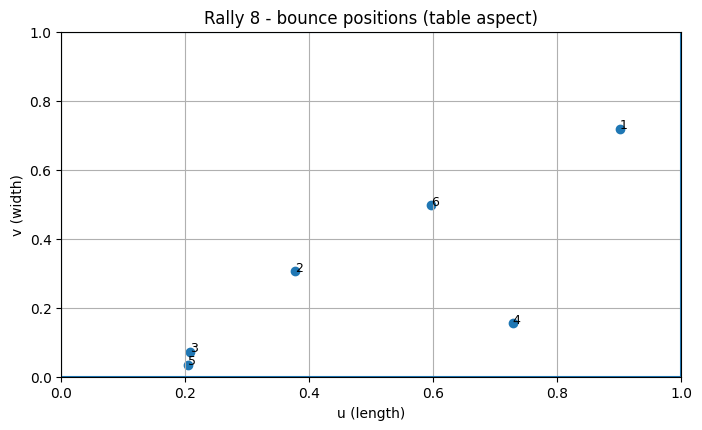

Rally 9: 21 bounces (frames 9743..11088)


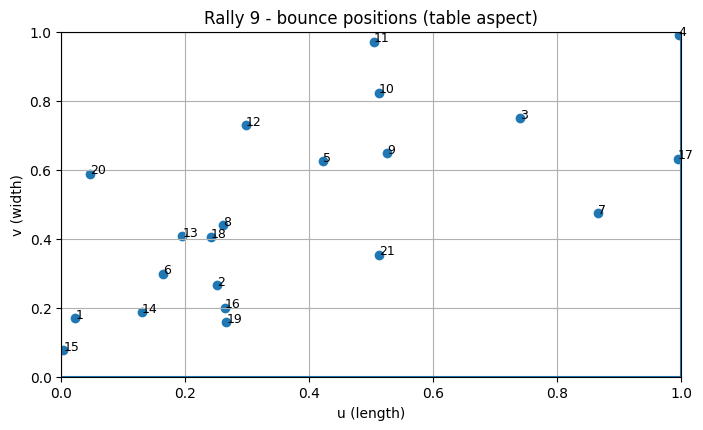

Rally 10: 2 bounces (frames 11501..11638)


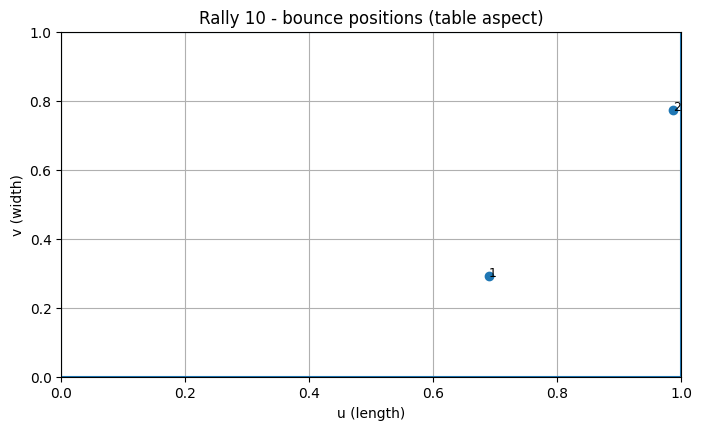

Rally 11: 9 bounces (frames 11890..12264)


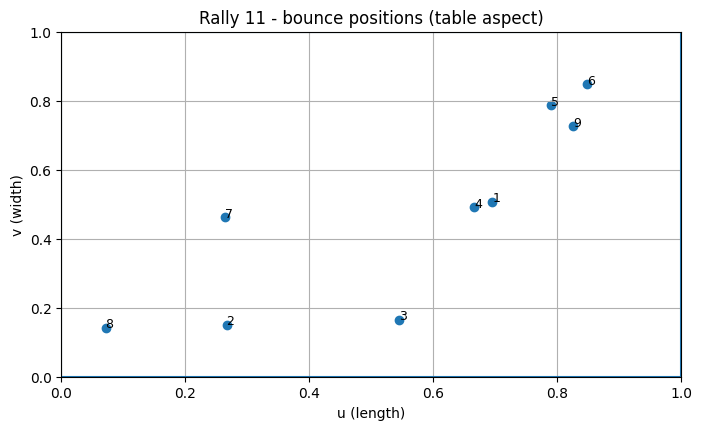

Rally 12: 15 bounces (frames 12506..13168)


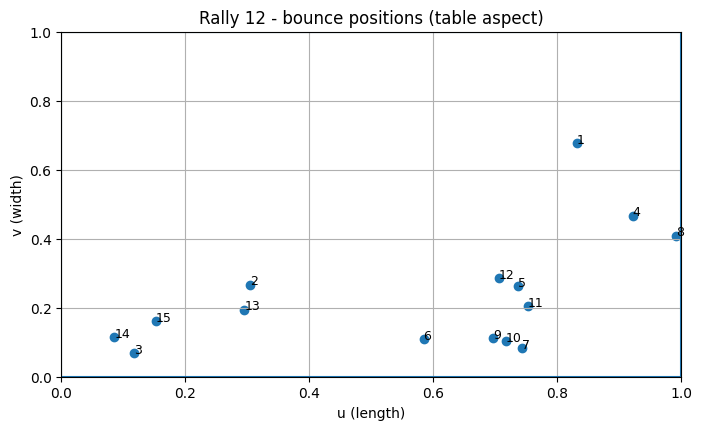

Rally 13: 14 bounces (frames 13451..14182)


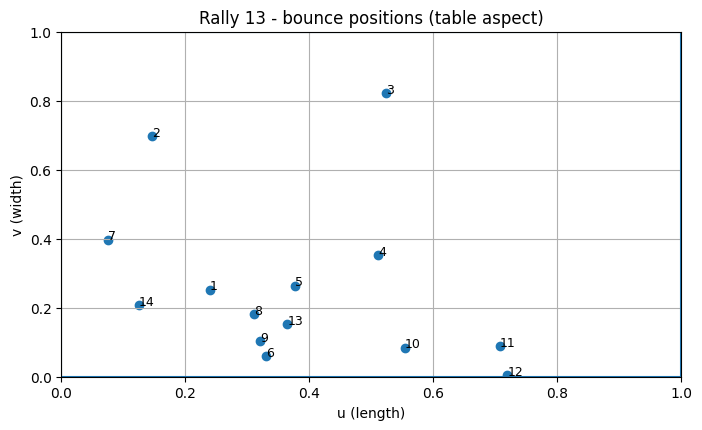

Rally 14: 17 bounces (frames 14478..15198)


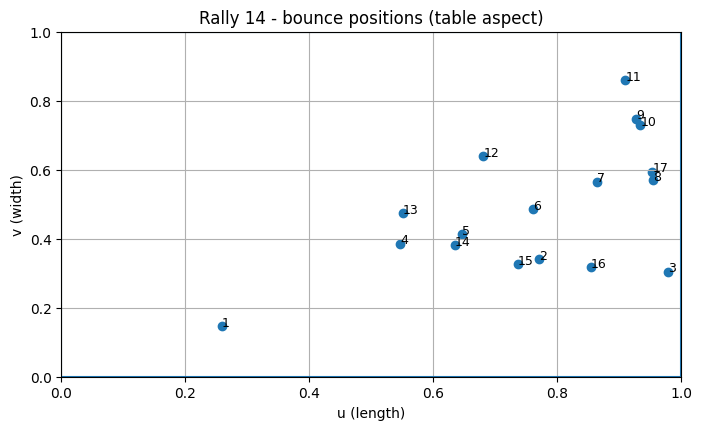

Rally 15: 19 bounces (frames 15444..16754)


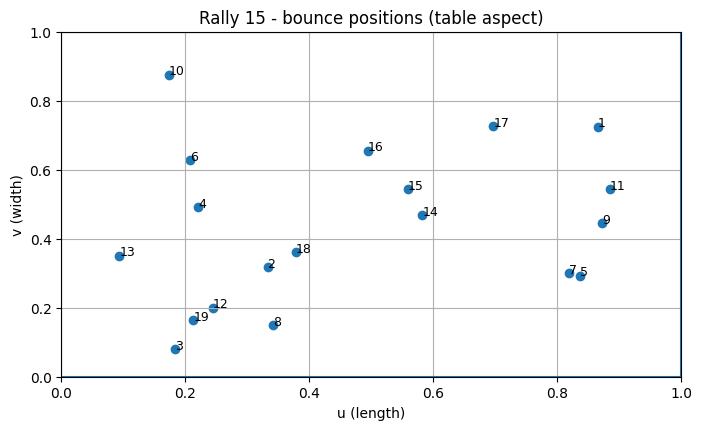

Rally 16: 14 bounces (frames 18196..19016)


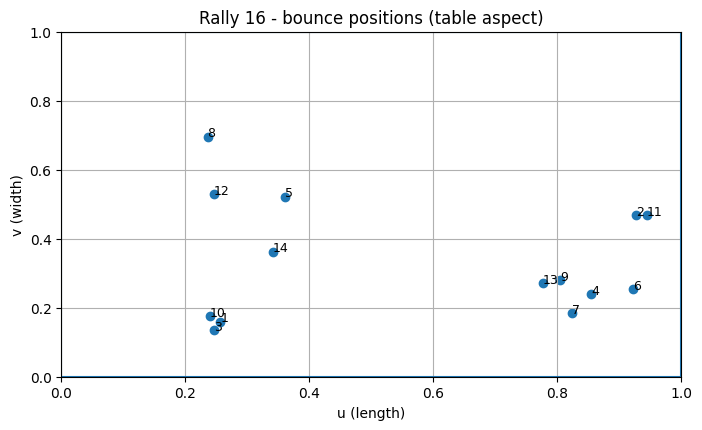

Rally 17: 20 bounces (frames 19996..21000)


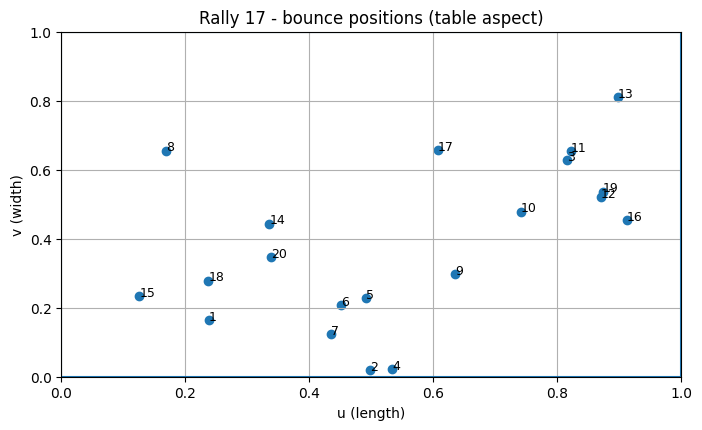

Rally 18: 15 bounces (frames 22221..22852)


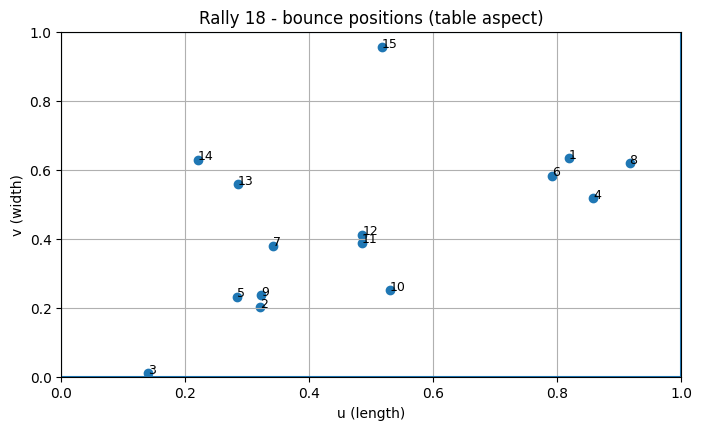

Rally 19: 14 bounces (frames 23333..24248)


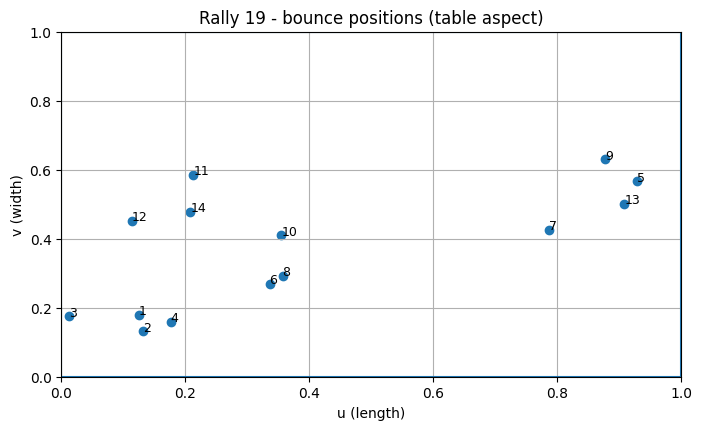

In [13]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# ====== 設定 ======
FPS = 120
GAP_SECONDS = 2.0                 # 何秒以上空いたら別ラリーにするか
GAP_FRAMES = int(FPS * GAP_SECONDS)

# Drive上のファイルパス（/content/drive/MyDrive/ 配下）
JSON_PATH = Path("/content/drive/MyDrive/ball_tracking_colabo/03_rally_plot/data/annotated_events.json")

# ====== Google Drive をマウント ======
from google.colab import drive
drive.mount("/content/drive")

# ====== JSON読み込み ======
if not JSON_PATH.exists():
    raise FileNotFoundError(f"JSONが見つかりません: {JSON_PATH}\n"
                            f"Drive上のパスが正しいか、data/annotated_events.json が存在するか確認してください。")

with JSON_PATH.open("r", encoding="utf-8") as f:
    events = json.load(f)

# ====== bounce のみ抽出 ======
bounces = [e for e in events if e.get("event") == "bounce" and "frame" in e]
bounces.sort(key=lambda e: e["frame"])

print(f"loaded events: {len(events)} / bounces: {len(bounces)}")
if not bounces:
    raise ValueError("bounce が1件もありませんでした（event=='bounce' を確認してください）")

# ====== ラリー分割（フレーム差で分ける） ======
rallies = []
current = [bounces[0]]

for prev, cur in zip(bounces, bounces[1:]):
    if (cur["frame"] - prev["frame"]) > GAP_FRAMES:
        rallies.append(current)
        current = [cur]
    else:
        current.append(cur)
rallies.append(current)

print(f"rallies detected: {len(rallies)} (gap>{GAP_FRAMES} frames = {GAP_SECONDS}s)")

# ====== プロット関数 ======
# 卓球台サイズ（国際規格）
TABLE_LENGTH_M = 2.74
TABLE_WIDTH_M  = 1.525
ASPECT_V_OVER_U = TABLE_WIDTH_M / TABLE_LENGTH_M  # v方向/ u方向（≈0.5562）

def plot_rally(rally, idx, use_uv=True):
    if use_uv:
        xs = [e.get("u") for e in rally]  # 0..1（長さ方向）
        ys = [e.get("v") for e in rally]  # 0..1（幅方向）
        xlab, ylab = "u (length)", "v (width)"
        title = f"Rally {idx} - bounce positions (table aspect)"
        xlim, ylim = (0, 1), (0, 1)
    else:
        xs = [e.get("x") for e in rally]
        ys = [e.get("y") for e in rally]
        xlab, ylab = "x", "y"
        title = f"Rally {idx} - bounce positions (x,y)"
        xlim, ylim = None, None

    pts = [(x, y) for x, y in zip(xs, ys) if x is not None and y is not None]
    if not pts:
        print(f"Rally {idx}: 有効な座標がありませんでした")
        return
    xs, ys = zip(*pts)

    plt.figure(figsize=(8, 8))  # 正方形キャンバスでも、アスペクトで台比率に揃う
    plt.scatter(xs, ys)

    # 連番ラベル
    for i, (x, y) in enumerate(zip(xs, ys), start=1):
        plt.text(x, y, str(i), fontsize=9)

    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    plt.grid(True)

    if xlim: plt.xlim(*xlim)
    if ylim: plt.ylim(*ylim)

    if use_uv:
        ax = plt.gca()
        # データ座標系で「幅/長さ = 1.525/2.74」になるように固定
        ax.set_aspect(ASPECT_V_OVER_U, adjustable="box")

        # 卓球台の枠線（0..1の矩形）を明示したい場合（任意）
        ax.plot([0,1,1,0,0], [0,0,1,1,0])

    plt.show()

# ====== ラリーごとに表示 ======
USE_UV = True  # アフィン変換後なら基本こっち（u,v）
for i, rally in enumerate(rallies, start=1):
    print(f"Rally {i}: {len(rally)} bounces (frames {rally[0]['frame']}..{rally[-1]['frame']})")
    plot_rally(rally, i, use_uv=USE_UV)
